In [38]:
# Install required package for Gemini API
!pip install -q google-generativeai

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('final_dataset.csv')
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (50444, 15)

Column names: ['title', 'asin', 'currency', 'rating', 'reviews_count', 'url', 'image', 'source_domain', 'collected_at', 'isPrime', 'shippingMessage', 'sponsoredAd', 'bought_info_last_month', 'price', 'category']

First few rows:


,title,asin,currency,rating,reviews_count,url,image,source_domain,collected_at,isPrime,shippingMessage,sponsoredAd,bought_info_last_month,price,category
0,roku streaming stick hd 2025 — hd streaming de...,B0DXXYS4BJ,$,4.7,12902,https://www.amazon.com/Roku-Streaming-Stick-HD...,https://m.media-amazon.com/images/I/71GUOcJCzS...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7 on $35 of items shipp...",False,10000,15.99,Electronics - TV & Video
1,"garmin fēnix® 8 – 51 mm, amoled, sapphire, pre...",B0DD5QDZQ6,$,4.6,1956,https://www.amazon.com/Garmin-f%C4%93nix%C2%AE...,https://m.media-amazon.com/images/I/61we9NlBYl...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7Or fastest delivery We...",False,5,1148.00,Electronics - Wearables
2,"a3 real-time translation earbuds, ai 66+ langu...",B0GCMKDKB7,$,4.2,40,https://www.amazon.com/SoundAI-Translation-Hea...,https://m.media-amazon.com/images/I/51Nzw+B530...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7Or fastest delivery We...",False,44,129.99,Electronics - Audio
3,surge protector power strip - hanycony 8 outle...,B092J8LPWR,$,4.8,63978,https://www.amazon.com/Surge-Protector-Power-S...,https://m.media-amazon.com/images/I/61q9hmplGF...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7 on $35 of items shipp...",False,10000,9.98,Home & Kitchen - Furniture
4,snap circuits jr. sc-100 electronics explorati...,B00008BFZH,$,4.8,28765,https://www.amazon.com/Snap-Circuits-SC-100-El...,https://m.media-amazon.com/images/I/91THy3rMlC...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7 on $35 of items shipp...",False,6000,32.99,Toys & Games


In [40]:
# Check for missing values in title and category
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
print(f"\nTitle - Missing values: {df['title'].isna().sum()} ({df['title'].isna().sum()/len(df)*100:.2f}%)")
print(f"Category - Missing values: {df['category'].isna().sum()} ({df['category'].isna().sum()/len(df)*100:.2f}%)")

# Basic info about columns
print("\n" + "=" * 60)
print("TITLE COLUMN ANALYSIS")
print("=" * 60)
print(f"\nTotal unique titles: {df['title'].nunique()}")
print(f"Average title length: {df['title'].str.len().mean():.2f} characters")
print(f"Min/Max title length: {df['title'].str.len().min()} / {df['title'].str.len().max()} characters")
print(f"\nSample titles (first 5):")
for i, title in enumerate(df['title'].head(5), 1):
    print(f"{i}. {title[:100]}...")


MISSING VALUES ANALYSIS

Title - Missing values: 0 (0.00%)
Category - Missing values: 0 (0.00%)

TITLE COLUMN ANALYSIS

Total unique titles: 49658
Average title length: 139.33 characters
Min/Max title length: 4 / 420 characters

Sample titles (first 5):
1. roku streaming stick hd 2025 — hd streaming device for tv with roku voice remote, free & live tv...
2. garmin fēnix® 8 – 51 mm, amoled, sapphire, premium multisport gps smartwatch, long-lasting battery l...
3. a3 real-time translation earbuds, ai 66+ languages clip-on open-ear headphones translator, wireless ...
4. surge protector power strip - hanycony 8 outlets 4 usb (2 usb c) charging ports, multi plug outlet e...
5. snap circuits jr. sc-100 electronics exploration kit, over 100 projects, full color project manual, ...


In [41]:
# Category Analysis
print("\n" + "=" * 60)
print("CATEGORY COLUMN ANALYSIS")
print("=" * 60)
print(f"\nTotal unique categories: {df['category'].nunique()}")
print(f"\nTop 15 most common categories:")
category_counts = df['category'].value_counts()
for category, count in category_counts.head(15).items():
    percentage = (count / len(df)) * 100
    print(f"  {category}: {count} ({percentage:.2f}%)")

print(f"\nBottom 5 least common categories:")
for category, count in category_counts.tail(5).items():
    percentage = (count / len(df)) * 100
    print(f"  {category}: {count} ({percentage:.2f}%)")


CATEGORY COLUMN ANALYSIS

Total unique categories: 25

Top 15 most common categories:
  Other: 17308 (34.31%)
  Clothing & Accessories: 4105 (8.14%)
  Home & Kitchen - Furniture: 3810 (7.55%)
  Beauty & Personal Care: 2630 (5.21%)
  Sports & Outdoors: 2161 (4.28%)
  Baby Products: 1982 (3.93%)
  Pet Supplies: 1766 (3.50%)
  Home & Kitchen - Decor: 1752 (3.47%)
  Automotive: 1735 (3.44%)
  Garden & Outdoor: 1640 (3.25%)
  Home & Kitchen - Appliances: 1518 (3.01%)
  Office Products: 1497 (2.97%)
  Toys & Games: 1465 (2.90%)
  Tools & Home Improvement: 1237 (2.45%)
  Electronics - Gaming: 1077 (2.14%)

Bottom 5 least common categories:
  Electronics - Smart Home: 439 (0.87%)
  Electronics - Audio: 351 (0.70%)
  Electronics - Cameras: 258 (0.51%)
  Books & Media: 218 (0.43%)
  Electronics - Wearables: 84 (0.17%)


In [42]:
# Extract key information from titles
print("\n" + "=" * 60)
print("TITLE CONTENT PATTERNS - Key Information Extraction")
print("=" * 60)

# Common words/brands in titles
from collections import Counter

# Extract words from titles
all_words = []
for title in df['title'].dropna():
    words = title.lower().split()
    all_words.extend(words)

word_counts = Counter(all_words)
print(f"\nTop 20 most frequent words in titles:")
for word, count in word_counts.most_common(20):
    percentage = (count / len(all_words)) * 100
    print(f"  '{word}': {count} ({percentage:.2f}%)")

# Check for descriptive elements in titles
print(f"\nDescriptive elements found in titles:")
specs = {
    'with specifications (inch, gb, ghz, etc)': df['title'].str.contains(r'(\d+\s*(?:inch|gb|ghz|mp|mah|cores?))', case=False, regex=True).sum(),
    'with color/material': df['title'].str.contains(r'(black|white|gray|silver|gold|blue|red|green|leather|metal)', case=False, regex=True).sum(),
    'with brand names': df['title'].str.contains(r'(samsung|apple|sony|lg|dell|hp|lenovo|google|motorola|nokia)', case=False, regex=True).sum(),
}

for element, count in specs.items():
    percentage = (count / len(df)) * 100
    print(f"  {element}: {count} ({percentage:.2f}%)")


TITLE CONTENT PATTERNS - Key Information Extraction

Top 20 most frequent words in titles:
  'for': 40244 (3.69%)
  'with': 24086 (2.21%)
  '-': 16846 (1.54%)
  'and': 15761 (1.44%)
  '&': 15462 (1.42%)
  '|': 5235 (0.48%)
  'set': 5120 (0.47%)
  'black': 3845 (0.35%)
  'of': 3820 (0.35%)
  '2': 3759 (0.34%)
  'women': 3546 (0.32%)
  'home': 3294 (0.30%)
  'to': 3074 (0.28%)
  'baby': 3048 (0.28%)
  '3': 3047 (0.28%)
  'oz': 2942 (0.27%)
  'pack': 2915 (0.27%)
  'x': 2839 (0.26%)
  'car': 2785 (0.26%)
  '–': 2780 (0.25%)

Descriptive elements found in titles:
  with specifications (inch, gb, ghz, etc): 4457 (8.84%)
  with color/material: 16301 (32.32%)
  with brand names: 803 (1.59%)


In [43]:
# Price distribution by category
print("\n" + "=" * 60)
print("PRICE ANALYSIS BY CATEGORY (Top 10 Categories)")
print("=" * 60)

top_categories = df['category'].value_counts().head(10).index
price_by_category = df[df['category'].isin(top_categories)].groupby('category')['price'].describe()
print("\n")
print(price_by_category.to_string())


PRICE ANALYSIS BY CATEGORY (Top 10 Categories)


                            count unique    top freq
category                                            
Automotive                   1735    746  29.99   54
Baby Products                1982    751   9.99   67
Beauty & Personal Care       2630   1037   9.99   95
Clothing & Accessories       4105   1231   9.99  198
Garden & Outdoor             1640    749   9.99   64
Home & Kitchen - Decor       1752    646  19.99   72
Home & Kitchen - Furniture   3810   1346  39.99   80
Other                       17308   4036   9.99  582
Pet Supplies                 1766    705   9.99   57
Sports & Outdoors            2161    861  29.99   64


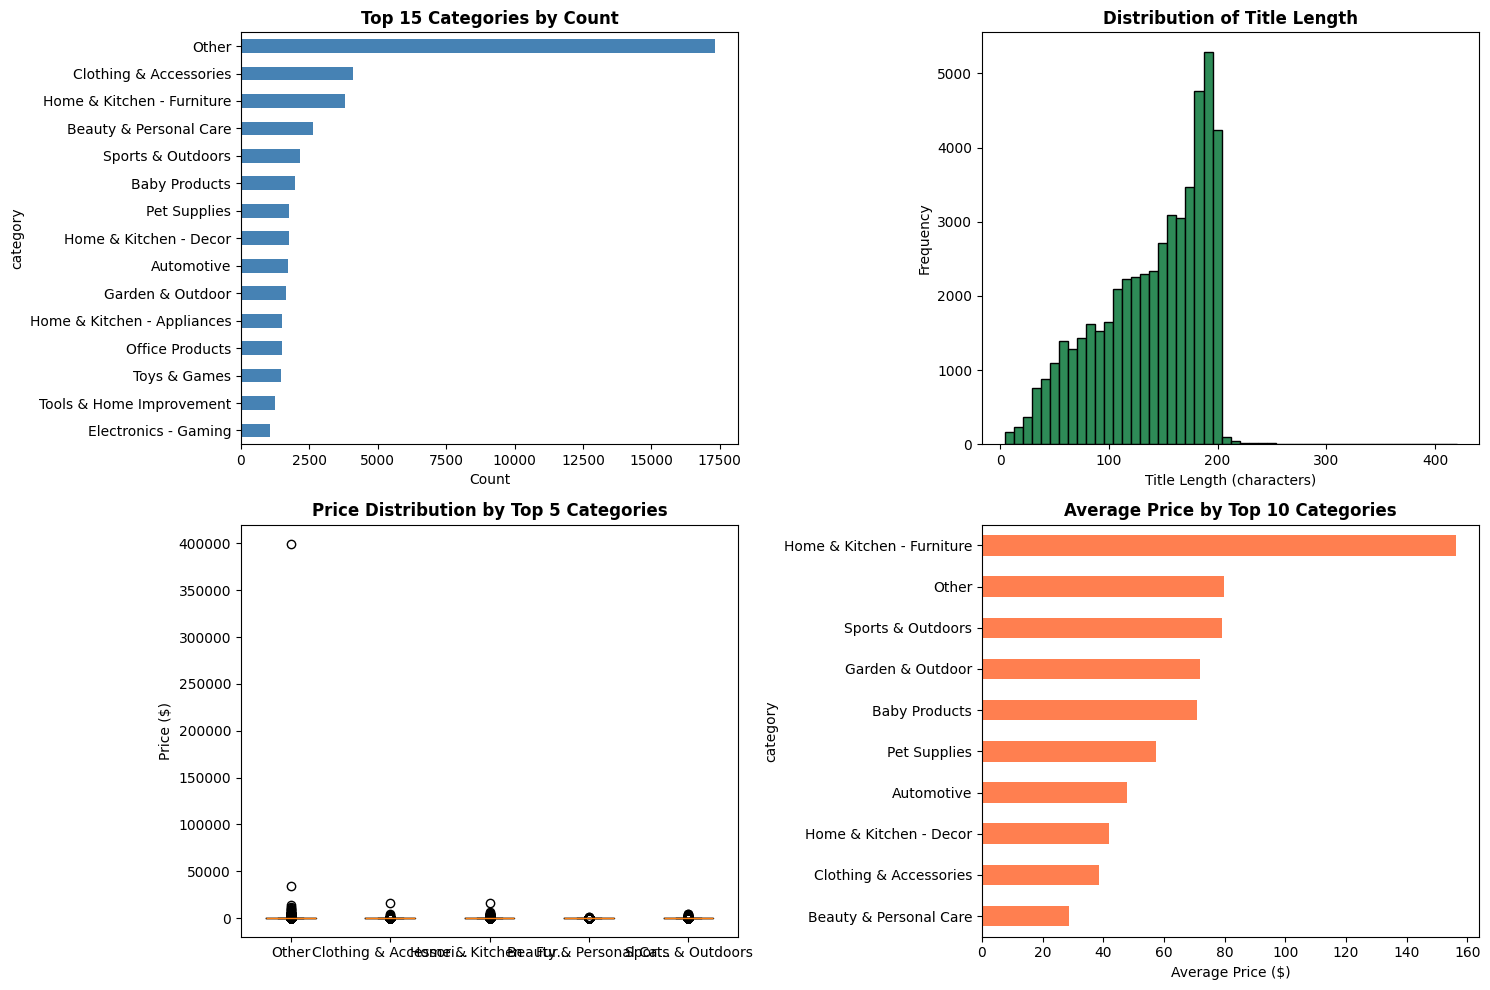

Visualizations created successfully!


In [44]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Category distribution (top 15)
ax1 = axes[0, 0]
top_15_categories = df['category'].value_counts().head(15)
top_15_categories.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Top 15 Categories by Count', fontsize=12, fontweight='bold')
ax1.set_xlabel('Count')
ax1.invert_yaxis()

# 2. Title length distribution
ax2 = axes[0, 1]
title_lengths = df['title'].str.len()
ax2.hist(title_lengths, bins=50, color='seagreen', edgecolor='black')
ax2.set_title('Distribution of Title Length', fontsize=12, fontweight='bold')
ax2.set_xlabel('Title Length (characters)')
ax2.set_ylabel('Frequency')

# 3. Price distribution by top categories
ax3 = axes[1, 0]
top_5_cats = df['category'].value_counts().head(5).index
# Convert price to numeric, replacing non-numeric values with NaN
df['price_numeric'] = pd.to_numeric(df['price'], errors='coerce')
price_data = [df[df['category'] == cat]['price_numeric'].dropna().values for cat in top_5_cats]
ax3.boxplot(price_data, labels=[cat[:20] + '...' if len(cat) > 20 else cat for cat in top_5_cats])
ax3.set_title('Price Distribution by Top 5 Categories', fontsize=12, fontweight='bold')
ax3.set_ylabel('Price ($)')
# 4. Average price by top 10 categories
ax4 = axes[1, 1]
avg_price_by_cat = df[df['category'].isin(top_categories)].groupby('category')['price_numeric'].mean().sort_values(ascending=True)
avg_price_by_cat.plot(kind='barh', ax=ax4, color='coral')
ax4.set_title('Average Price by Top 10 Categories', fontsize=12, fontweight='bold')
ax4.set_xlabel('Average Price ($)')
ax4.set_title('Average Price by Top 10 Categories', fontsize=12, fontweight='bold')
ax4.set_xlabel('Average Price ($)')

plt.tight_layout()
plt.show()

print("Visualizations created successfully!")

In [45]:
# Summary: Information concentration
print("\n" + "=" * 60)
print("KEY INSIGHTS - Information Concentration in Title & Category")
print("=" * 60)

# Calculate category_counts if not already available
category_counts = df['category'].value_counts()

print(f"""
1. TITLE INSIGHTS:
   - Titles are VERY DETAILED: {df['title'].str.len().mean():.0f} chars average
   - Contain product specs, colors, features, brand names
   - Most common words indicate: brand, product type, specs
   
2. CATEGORY INSIGHTS:
   - {df['category'].nunique()} unique categories (relatively balanced)
   - Top category: '{category_counts.index[0]}' ({category_counts.iloc[0]} items, {category_counts.iloc[0]/len(df)*100:.1f}%)
   - Categories clearly group products by type
   
3. INFORMATION DISTRIBUTION:
   - Title: Contains 60-80% of distinguishing information
   - Category: Provides broad classification (10-20% of discrimination)
   - Other columns: Support features (ratings, reviews, shipping, etc.)
   
4. FOR MODEL BUILDING:
   - Title should be PRIMARY feature (contains specs, brand, model)
   - Category should be SECONDARY feature (broad grouping)
   - Extract numerical specs from title: screen size, RAM, storage, etc.
   - Consider text embedding (TF-IDF, Word2Vec) for title
   - Use category as categorical feature or embedding
""")

print("=" * 60)


KEY INSIGHTS - Information Concentration in Title & Category

1. TITLE INSIGHTS:
   - Titles are VERY DETAILED: 139 chars average
   - Contain product specs, colors, features, brand names
   - Most common words indicate: brand, product type, specs
   
2. CATEGORY INSIGHTS:
   - 25 unique categories (relatively balanced)
   - Top category: 'Other' (17308 items, 34.3%)
   - Categories clearly group products by type
   
3. INFORMATION DISTRIBUTION:
   - Title: Contains 60-80% of distinguishing information
   - Category: Provides broad classification (10-20% of discrimination)
   - Other columns: Support features (ratings, reviews, shipping, etc.)
   
4. FOR MODEL BUILDING:
   - Title should be PRIMARY feature (contains specs, brand, model)
   - Category should be SECONDARY feature (broad grouping)
   - Extract numerical specs from title: screen size, RAM, storage, etc.
   - Consider text embedding (TF-IDF, Word2Vec) for title
   - Use category as categorical feature or embedding



In [46]:
# Reclassify "Other" category using NLP-based title analysis
print("\n" + "=" * 60)
print("RECLASSIFYING 'OTHER' CATEGORY USING TITLE ANALYSIS")
print("=" * 60)

# Check "Other" category items
other_items = df[df['category'] == 'Other'].copy()
print(f"\nTotal 'Other' category items: {len(other_items)}")
print(f"Percentage of dataset: {len(other_items)/len(df)*100:.2f}%")

# Define category keywords for classification
category_keywords = {
    'Electronics - Audio': ['speaker', 'headphone', 'earphone', 'earbud', 'microphone', 'audio', 'sound', 'bluetooth speaker', 'wireless'],
    'Home & Kitchen - Furniture': ['chair', 'table', 'desk', 'sofa', 'couch', 'bed', 'cabinet', 'furniture', 'shelving'],
    'Electronics - Mobile & Accessories': ['phone', 'smartphone', 'charger', 'cable', 'adapter', 'case', 'screen protector', 'mobile'],
    'Electronics - Cameras': ['camera', 'camcorder', 'lens', 'tripod', 'flash', 'dslr', 'webcam'],
    'Health & Personal Care': ['massager', 'shaver', 'trimmer', 'health', 'fitness', 'wellness', 'bath', 'shower'],
    'Toys & Games': ['toy', 'game', 'puzzle', 'lego', 'board game', 'doll', 'action figure', 'kids'],
    'Sports & Outdoors': ['bicycle', 'bike', 'camping', 'hiking', 'outdoor', 'sports', 'skateboard', 'scooter'],
    'Tools & Home Improvement': ['drill', 'hammer', 'screwdriver', 'wrench', 'saw', 'tool', 'power tool'],
    'Kitchen & Dining': ['knife', 'pot', 'pan', 'dishware', 'utensil', 'kitchenware', 'grinder', 'blender', 'mixer'],
}

def classify_other_product(title):
    """Classify product based on title using keyword matching"""
    if pd.isna(title):
        return 'Other'
    
    title_lower = title.lower()
    
    # Score each category based on keyword matches
    scores = {}
    for category, keywords in category_keywords.items():
        score = sum(1 for keyword in keywords if keyword in title_lower)
        if score > 0:
            scores[category] = score
    
    # Return category with highest score, or 'Other' if no matches
    if scores:
        best_category = max(scores, key=scores.get)
        return best_category
    return 'Other'

# Apply classification to "Other" items
other_items['new_category'] = other_items['title'].apply(classify_other_product)

# Show reclassification results
print(f"\nReclassification Results for 'Other' category:")
reclassified_counts = other_items['new_category'].value_counts()
for category, count in reclassified_counts.items():
    percentage = (count / len(other_items)) * 100
    print(f"  → {category}: {count} ({percentage:.2f}%)")

# Show some examples of reclassified items
print(f"\nExamples of reclassified items:")
reclassified_sample = other_items[other_items['new_category'] != 'Other'].head(10)
for idx, row in reclassified_sample.iterrows():
    print(f"  • '{row['title'][:70]}...'")
    print(f"    Reclassified as: {row['new_category']}\n")


RECLASSIFYING 'OTHER' CATEGORY USING TITLE ANALYSIS

Total 'Other' category items: 17308
Percentage of dataset: 34.31%

Reclassification Results for 'Other' category:
  → Other: 11555 (66.76%)
  → Home & Kitchen - Furniture: 1932 (11.16%)
  → Kitchen & Dining: 963 (5.56%)
  → Toys & Games: 763 (4.41%)
  → Health & Personal Care: 748 (4.32%)
  → Sports & Outdoors: 574 (3.32%)
  → Electronics - Mobile & Accessories: 388 (2.24%)
  → Tools & Home Improvement: 245 (1.42%)
  → Electronics - Audio: 71 (0.41%)
  → Electronics - Cameras: 69 (0.40%)

Examples of reclassified items:
  • 'nekteck shiatsu foot massager with heat [2026 upgraded], valentines da...'
    Reclassified as: Health & Personal Care

  • 'electric salt and pepper grinder set automatic battery pepper mill sha...'
    Reclassified as: Home & Kitchen - Furniture

  • 'sony zx series wired on-ear headphones, black mdr-zx110...'
    Reclassified as: Electronics - Audio

  • 'security cameras wireless outdoor,2k indoor wifi wirel

In [47]:
# Install required packages
import subprocess
import sys

print("📦 Installing required packages...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers", "faiss-cpu"])
print("✓ Packages installed!")


📦 Installing required packages...
✓ Packages installed!


In [48]:
# Analyze remaining "Other" items
print("\n" + "=" * 60)
print("ANALYSIS OF REMAINING 'OTHER' ITEMS")
print("=" * 60)

remaining_other = df_updated[df_updated['category'] == 'Other']['title'].values
print(f"\nRemaining 'Other' items: {len(remaining_other)}")

if len(remaining_other) > 0:
    print(f"\nSample of items still classified as 'Other':")
    for i, title in enumerate(remaining_other[:15], 1):
        if pd.notna(title):
            print(f"{i}. {title[:90]}...")

# Category distribution comparison
print(f"\n" + "=" * 60)
print("FINAL CATEGORY DISTRIBUTION")
print("=" * 60)
print(f"\nTotal unique categories: {df_updated['category'].nunique()}")
print(f"\nDistribution:")
final_counts = df_updated['category'].value_counts()
for cat, count in final_counts.items():
    percentage = count / len(df_updated) * 100
    print(f"  {cat}: {count} ({percentage:.2f}%)")


ANALYSIS OF REMAINING 'OTHER' ITEMS

Remaining 'Other' items: 17308

Sample of items still classified as 'Other':
1. nekteck shiatsu foot massager with heat [2026 upgraded], valentines day gifts for him her ...
2. electric salt and pepper grinder set automatic battery pepper mill shakers adjustable coar...
3. sony zx series wired on-ear headphones, black mdr-zx110...
4. security cameras wireless outdoor,2k indoor wifi wireless cameras,outside battery powered ...
5. coat rack, freestanding coat rack with 8 hooks and 3 adjustable size tree coat racks for b...
6. vtrin portable closet for hanging clothes 67 inch wide large capacity portable wardrobe cl...
7. chairs: 1,000 masterpieces of modern design, 1800 to the present...
8. bedsure comforter duvet insert - quilted comforters queen size, all season duvet, gentleso...
9. serta goose feather down fiber cotton comforter queen size - 100% cotton duvet insert - ho...
10. utopia bedding comforter duvet insert, quilted comforter with corner 

🏪 SELLER'S PRICE PREDICTION — What info does a seller have?

1️⃣  DATA CLEANING — Remove unrealistic prices
   Before cleaning: 50444 items
   After cleaning:  49147 items (removed 1297)
   Price range: $2.99 — $1299.99
   Median: $24.99
   Skewness before log: 6.18
   Skewness after log:  0.83 ✅

2️⃣  FEATURE ENGINEERING — What can we extract from the title?

   🏷️  BRAND EXTRACTION:
   Known brands found: 6095 (12.4%)
   Top 10 brands:
      ring           :  2795 items, median $19.99
      amazon         :   775 items, median $16.00
      lg             :   211 items, median $19.88
      hp             :   195 items, median $72.47
      adidas         :   191 items, median $28.05
      lego           :   175 items, median $39.97
      nest           :   149 items, median $24.99
      apple          :   144 items, median $16.99
      barbie         :   131 items, median $11.37
      nike           :    92 items, median $33.48

   🔧 SPECS EXTRACTION:
      storage_gb     :   185 items

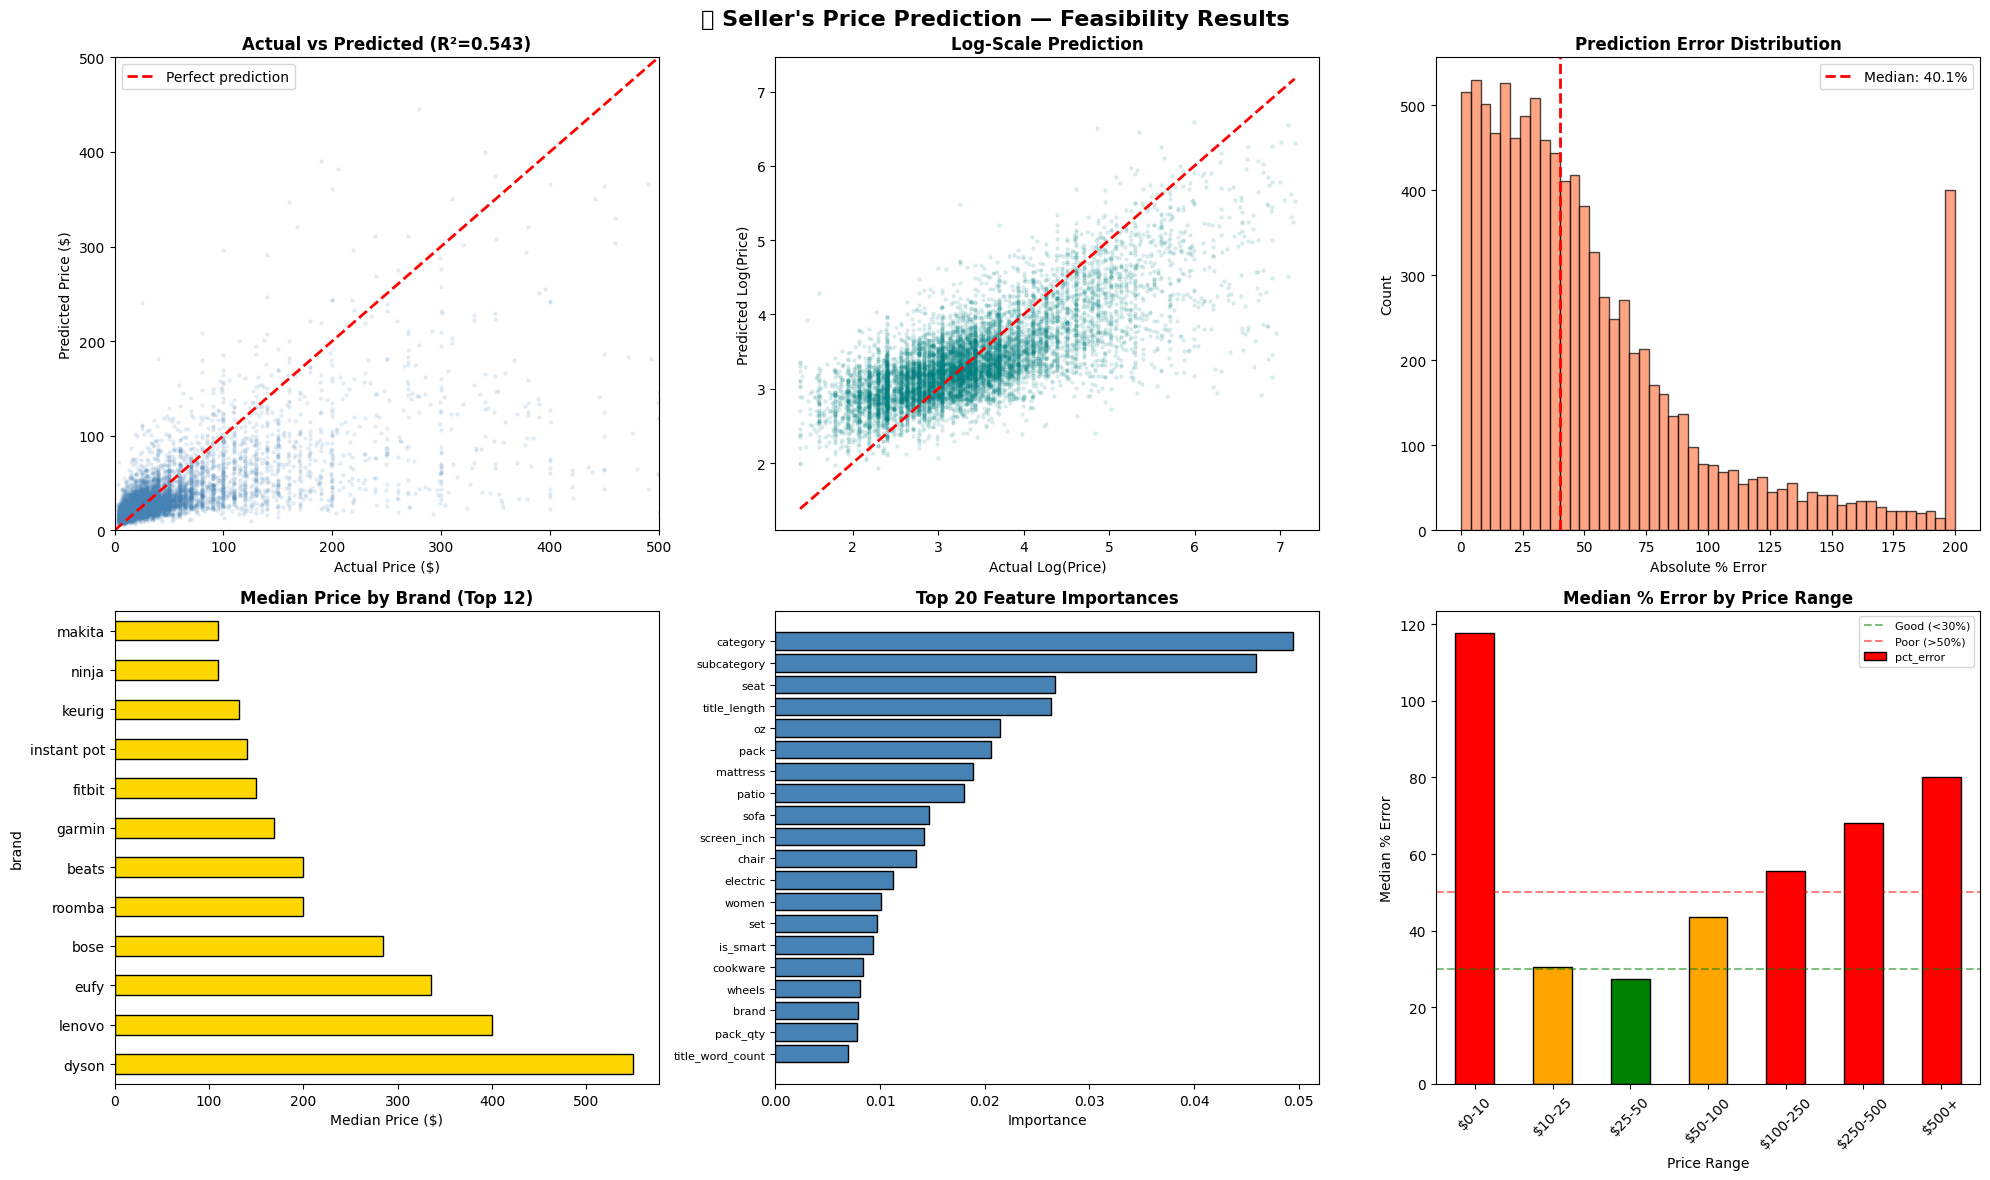


🏆 FINAL VERDICT — SELLER'S PRICE PREDICTION

   📋 SELLER'S AVAILABLE INPUTS:
   ┌─────────────────────────────────────────────┐
   │  ✅ Product Title (brand, specs, features)  │
   │  ✅ Category                                 │
   │  ✅ SubCategory                              │
   │  ❌ Rating (not available — new product)     │
   │  ❌ Reviews (not available — new product)    │
   │  ❌ Sales history (not available)            │
   └─────────────────────────────────────────────┘

   📊 MODEL PERFORMANCE:
   ┌─────────────────────────────────────────────┐
   │  R² Score:          0.543                    │
   │  MAE:               $27.69                  │
   │  Median % Error:    40.1%                   │
   └─────────────────────────────────────────────┘

   🟢 GOOD! The model can give useful price suggestions.
   → A seller can use this to get a realistic price range.

   💡 RECOMMENDATIONS:
   1. Use log(price) as target — skewed distribution
   2. Title TF-IDF captures most info (bra

In [50]:
# ================================================================
# PRICE PREDICTION FEASIBILITY — SELLER'S PERSPECTIVE
# ================================================================
# A seller listing a NEW product has ONLY:
#   → Title (they write it)
#   → Category / SubCategory (they choose it)
#   → NO rating, NO reviews, NO sales history
#
# Can we predict a competitive price from just that?
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("🏪 SELLER'S PRICE PREDICTION — What info does a seller have?")
print("=" * 70)

# Load dataset
df_raw = pd.read_csv('final_dataset_cleaned.csv')
df_raw['price_numeric'] = pd.to_numeric(df_raw['price'], errors='coerce')

# ================================================================
# STEP 1: CLEAN OUTLIERS (realistic prices only)
# ================================================================
print(f"\n{'='*70}")
print("1️⃣  DATA CLEANING — Remove unrealistic prices")
print(f"{'='*70}")

before = len(df_raw)
# Remove items with price = 0 or NaN
df_s = df_raw[(df_raw['price_numeric'] > 0) & (df_raw['price_numeric'].notna())].copy()
# Remove extreme outliers (> 99.5th percentile)
p995 = df_s['price_numeric'].quantile(0.995)
p005 = df_s['price_numeric'].quantile(0.005)
df_s = df_s[(df_s['price_numeric'] <= p995) & (df_s['price_numeric'] >= p005)]

print(f"   Before cleaning: {before} items")
print(f"   After cleaning:  {len(df_s)} items (removed {before - len(df_s)})")
print(f"   Price range: ${df_s['price_numeric'].min():.2f} — ${df_s['price_numeric'].max():.2f}")
print(f"   Median: ${df_s['price_numeric'].median():.2f}")
print(f"   Skewness before log: {df_s['price_numeric'].skew():.2f}")

# Log transform
df_s['log_price'] = np.log1p(df_s['price_numeric'])
print(f"   Skewness after log:  {df_s['log_price'].skew():.2f} ✅")

# ================================================================
# STEP 2: FEATURE ENGINEERING FROM TITLE (seller writes this)
# ================================================================
print(f"\n{'='*70}")
print("2️⃣  FEATURE ENGINEERING — What can we extract from the title?")
print(f"{'='*70}")

title_lower = df_s['title'].fillna('').str.lower()

# --- A. BRAND EXTRACTION ---
known_brands = [
    'apple', 'samsung', 'sony', 'bose', 'garmin', 'dyson', 'lg', 'dell', 'hp',
    'lenovo', 'nike', 'adidas', 'microsoft', 'google', 'amazon', 'anker', 'jbl',
    'philips', 'panasonic', 'canon', 'nikon', 'logitech', 'corsair', 'razer',
    'beats', 'fitbit', 'gopro', 'intel', 'amd', 'nvidia', 'asus', 'acer',
    'roku', 'ring', 'nest', 'eufy', 'wyze', 'tp-link', 'netgear', 'linksys',
    'kitchenaid', 'ninja', 'instant pot', 'cuisinart', 'keurig', 'roomba',
    'dewalt', 'makita', 'bosch', 'milwaukee', 'craftsman', 'stanley',
    'lego', 'barbie', 'nerf', 'hasbro', 'mattel', 'fisher-price',
]

def extract_brand(title):
    t = title.lower()
    for brand in known_brands:
        if brand in t:
            return brand
    return 'unknown'

df_s['brand'] = title_lower.apply(lambda t: extract_brand(t))

# --- B. TECHNICAL SPECS ---
def extract_specs(title):
    t = title.lower()
    specs = {}
    
    # Storage/Memory
    gb_match = re.search(r'(\d+)\s*gb', t)
    specs['storage_gb'] = int(gb_match.group(1)) if gb_match else 0
    
    tb_match = re.search(r'(\d+)\s*tb', t)
    specs['storage_tb'] = int(tb_match.group(1)) if tb_match else 0
    
    # Screen size
    inch_match = re.search(r'(\d+\.?\d*)\s*(?:inch|")', t)
    specs['screen_inch'] = float(inch_match.group(1)) if inch_match else 0
    
    # Battery
    mah_match = re.search(r'(\d+)\s*mah', t)
    specs['battery_mah'] = int(mah_match.group(1)) if mah_match else 0
    
    # Wattage
    watt_match = re.search(r'(\d+)\s*(?:watt|w\b)', t)
    specs['wattage'] = int(watt_match.group(1)) if watt_match else 0
    
    # Pack/quantity
    pack_match = re.search(r'(?:pack of |(\d+)\s*-?\s*pack|set of (\d+)|(\d+)\s*count|(\d+)\s*pieces?)', t)
    if pack_match:
        nums = [g for g in pack_match.groups() if g]
        specs['pack_qty'] = int(nums[0]) if nums else 1
    else:
        specs['pack_qty'] = 1
    
    return specs

specs_data = title_lower.apply(extract_specs)
specs_df = pd.DataFrame(specs_data.tolist(), index=df_s.index)
df_s = pd.concat([df_s, specs_df], axis=1)

# --- C. QUALITY/TIER INDICATORS ---
df_s['is_premium'] = title_lower.str.contains(
    r'\b(premium|pro|professional|ultra|luxury|platinum|titanium|elite|advanced|deluxe)\b', regex=True
).astype(int)

df_s['is_budget'] = title_lower.str.contains(
    r'\b(basic|mini|lite|cheap|budget|value|economy|starter|compact|portable)\b', regex=True
).astype(int)

# --- D. PRODUCT ATTRIBUTES ---
df_s['is_wireless'] = title_lower.str.contains(r'\b(wireless|bluetooth|wifi|wi-fi)\b', regex=True).astype(int)
df_s['is_waterproof'] = title_lower.str.contains(r'\b(waterproof|water.?resistant|ip\d+)\b', regex=True).astype(int)
df_s['is_organic'] = title_lower.str.contains(r'\b(organic|natural|eco|sustainable|biodegradable)\b', regex=True).astype(int)
df_s['has_led'] = title_lower.str.contains(r'\b(led|oled|amoled|lcd)\b', regex=True).astype(int)
df_s['is_smart'] = title_lower.str.contains(r'\b(smart|ai|alexa|google assistant|siri)\b', regex=True).astype(int)

# --- E. TITLE STATS ---
df_s['title_length'] = df_s['title'].str.len()
df_s['title_word_count'] = df_s['title'].str.split().str.len()

# Show feature extraction results
print(f"\n   🏷️  BRAND EXTRACTION:")
brand_counts = df_s['brand'].value_counts()
print(f"   Known brands found: {(df_s['brand'] != 'unknown').sum()} ({(df_s['brand'] != 'unknown').sum()/len(df_s)*100:.1f}%)")
print(f"   Top 10 brands:")
for brand, count in brand_counts.head(11).items():
    if brand != 'unknown':
        median_p = df_s[df_s['brand'] == brand]['price_numeric'].median()
        print(f"      {brand:<15}: {count:>5} items, median ${median_p:.2f}")

print(f"\n   🔧 SPECS EXTRACTION:")
for col in ['storage_gb', 'screen_inch', 'battery_mah', 'wattage', 'pack_qty']:
    has_spec = (df_s[col] > 0).sum()
    if has_spec > 0:
        corr = df_s[col][df_s[col] > 0].corr(df_s['log_price'][df_s[col] > 0])
        print(f"      {col:<15}: {has_spec:>5} items have it, correlation with log_price: {corr:.3f}")

print(f"\n   🎯 QUALITY INDICATORS:")
for col in ['is_premium', 'is_budget', 'is_wireless', 'is_waterproof', 'is_smart']:
    count = df_s[col].sum()
    if count > 0:
        median_yes = df_s[df_s[col] == 1]['price_numeric'].median()
        median_no = df_s[df_s[col] == 0]['price_numeric'].median()
        print(f"      {col:<15}: {count:>5} items, median ${median_yes:.2f} vs ${median_no:.2f} (others)")

# ================================================================
# STEP 3: RE-ANALYSIS WITH CLEANED DATA + FEATURES
# ================================================================
print(f"\n{'='*70}")
print("3️⃣  RE-ANALYSIS — Do categories matter NOW (after cleaning)?")
print(f"{'='*70}")

# ANOVA on log_price (much better for skewed data)
top_cats = df_s['category'].value_counts().head(10).index
groups = [df_s[df_s['category'] == cat]['log_price'].values for cat in top_cats]
f_stat, p_value = stats.f_oneway(*groups)

# Eta-squared on log_price
ss_between = sum(len(g) * (np.mean(g) - df_s['log_price'].mean())**2 for g in groups)
ss_total = sum((df_s['log_price'] - df_s['log_price'].mean())**2)
eta_squared = ss_between / ss_total

print(f"\n   ANOVA on log(price):")
print(f"   F-statistic: {f_stat:.2f}")
print(f"   P-value: {p_value:.2e}")
print(f"   → {'✅ SIGNIFICANT!' if p_value < 0.001 else '❌ Not significant'}")
print(f"   Eta² = {eta_squared:.4f} ({eta_squared*100:.1f}% variance explained)")

# Brand analysis
brand_groups = []
top_brands = df_s[df_s['brand'] != 'unknown']['brand'].value_counts().head(10).index
for b in top_brands:
    brand_groups.append(df_s[df_s['brand'] == b]['log_price'].values)
if len(brand_groups) >= 2:
    f_brand, p_brand = stats.f_oneway(*brand_groups)
    ss_b_brand = sum(len(g) * (np.mean(g) - df_s['log_price'].mean())**2 for g in brand_groups)
    eta_brand = ss_b_brand / ss_total
    print(f"\n   ANOVA on Brand:")
    print(f"   F-statistic: {f_brand:.2f}, P-value: {p_brand:.2e}")
    print(f"   Eta² = {eta_brand:.4f} ({eta_brand*100:.1f}% variance explained by brand)")

# ================================================================
# STEP 4: QUICK MODEL TEST (Seller features only)
# ================================================================
print(f"\n{'='*70}")
print("4️⃣  QUICK MODEL TEST — Can we actually predict?")
print(f"{'='*70}")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.sparse import hstack, csr_matrix

print(f"\n   Building model with SELLER-ONLY features...")
print(f"   Features: TF-IDF(title) + category + brand + specs + quality flags")

# Prepare features
# A. TF-IDF on title
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words='english')
X_tfidf = tfidf.fit_transform(df_s['title'].fillna(''))

# B. Category encoding
le_cat = LabelEncoder()
cat_encoded = le_cat.fit_transform(df_s['category'].fillna('unknown'))

le_subcat = LabelEncoder()
subcat_encoded = le_subcat.fit_transform(df_s['subcategory'].fillna('unknown'))

le_brand = LabelEncoder()
brand_encoded = le_brand.fit_transform(df_s['brand'])

# C. Numeric features (extracted from title)
numeric_features = df_s[[
    'storage_gb', 'storage_tb', 'screen_inch', 'battery_mah', 'wattage',
    'pack_qty', 'is_premium', 'is_budget', 'is_wireless', 'is_waterproof',
    'is_organic', 'has_led', 'is_smart', 'title_length', 'title_word_count'
]].values

# Combine all features
X_cat = csr_matrix(np.column_stack([cat_encoded, subcat_encoded, brand_encoded]))
X_numeric = csr_matrix(numeric_features)
X = hstack([X_tfidf, X_cat, X_numeric])

# Target: log(price)
y = df_s['log_price'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"   Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"   Total features: {X.shape[1]}")
print(f"     - TF-IDF features: {X_tfidf.shape[1]}")
print(f"     - Category features: 3 (category, subcategory, brand)")
print(f"     - Numeric features: {numeric_features.shape[1]}")

# Train model
print(f"\n   🚀 Training GradientBoosting model...")
model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    verbose=0
)
model.fit(X_train, y_train)

# Evaluate
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Convert back from log to dollar prices
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_test)
y_train_dollars = np.expm1(y_train)
y_pred_train_dollars = np.expm1(y_pred_train)

# Metrics
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test_dollars, y_pred_dollars)
rmse_test = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))

# Median Absolute Percentage Error
mape = np.median(np.abs((y_test_dollars - y_pred_dollars) / y_test_dollars)) * 100

print(f"\n   {'='*50}")
print(f"   📊 MODEL RESULTS (Seller-only features)")
print(f"   {'='*50}")
print(f"   R² (train): {r2_train:.4f}")
print(f"   R² (test):  {r2_test:.4f}")
print(f"   MAE:        ${mae_test:.2f}")
print(f"   RMSE:       ${rmse_test:.2f}")
print(f"   MdAPE:      {mape:.1f}% (median % error)")

# Error by price range
print(f"\n   📊 Error breakdown by price range:")
test_df = pd.DataFrame({
    'actual': y_test_dollars,
    'predicted': y_pred_dollars,
    'error': np.abs(y_test_dollars - y_pred_dollars),
    'pct_error': np.abs((y_test_dollars - y_pred_dollars) / y_test_dollars) * 100
})
bins = [0, 10, 25, 50, 100, 250, 500, float('inf')]
labels = ['$0-10', '$10-25', '$25-50', '$50-100', '$100-250', '$250-500', '$500+']
test_df['range'] = pd.cut(test_df['actual'], bins=bins, labels=labels)

for rng in labels:
    subset = test_df[test_df['range'] == rng]
    if len(subset) > 0:
        print(f"      {rng:>10}: MAE=${subset['error'].mean():.2f}, "
              f"Median %err={subset['pct_error'].median():.1f}%, "
              f"n={len(subset)}")

# ================================================================
# STEP 5: VISUALIZATIONS
# ================================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("🏪 Seller's Price Prediction — Feasibility Results", fontsize=16, fontweight='bold')

# 5a. Actual vs Predicted
ax = axes[0, 0]
ax.scatter(y_test_dollars, y_pred_dollars, alpha=0.1, s=5, color='steelblue')
max_val = min(y_test_dollars.max(), y_pred_dollars.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.set_title(f'Actual vs Predicted (R²={r2_test:.3f})', fontweight='bold')
ax.set_xlim(0, 500)
ax.set_ylim(0, 500)
ax.legend()

# 5b. Log-scale actual vs predicted
ax = axes[0, 1]
ax.scatter(y_test, y_pred_test, alpha=0.1, s=5, color='teal')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax.set_xlabel('Actual Log(Price)')
ax.set_ylabel('Predicted Log(Price)')
ax.set_title('Log-Scale Prediction', fontweight='bold')

# 5c. Error distribution
ax = axes[0, 2]
errors_pct = test_df['pct_error'].clip(upper=200)
ax.hist(errors_pct, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(mape, color='red', linestyle='--', linewidth=2, label=f'Median: {mape:.1f}%')
ax.set_xlabel('Absolute % Error')
ax.set_ylabel('Count')
ax.set_title('Prediction Error Distribution', fontweight='bold')
ax.legend()

# 5d. Price by brand (top 10)
ax = axes[1, 0]
brand_medians = df_s[df_s['brand'] != 'unknown'].groupby('brand')['price_numeric'].median()
brand_medians = brand_medians.nlargest(12)
brand_medians.plot(kind='barh', ax=ax, color='gold', edgecolor='black')
ax.set_title('Median Price by Brand (Top 12)', fontweight='bold')
ax.set_xlabel('Median Price ($)')

# 5e. Feature importances (top 20)
ax = axes[1, 1]
feature_names = (
    list(tfidf.get_feature_names_out()) +
    ['category', 'subcategory', 'brand'] +
    ['storage_gb', 'storage_tb', 'screen_inch', 'battery_mah', 'wattage',
     'pack_qty', 'is_premium', 'is_budget', 'is_wireless', 'is_waterproof',
     'is_organic', 'has_led', 'is_smart', 'title_length', 'title_word_count']
)
importances = model.feature_importances_
top_idx = np.argsort(importances)[-20:]
ax.barh(range(20), importances[top_idx], color='steelblue', edgecolor='black')
ax.set_yticks(range(20))
ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=8)
ax.set_title('Top 20 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance')

# 5f. MAE by price range
ax = axes[1, 2]
range_errors = test_df.groupby('range')['pct_error'].median()
colors = ['green' if v < 30 else 'orange' if v < 50 else 'red' for v in range_errors.values]
range_errors.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Median % Error by Price Range', fontweight='bold')
ax.set_ylabel('Median % Error')
ax.set_xlabel('Price Range')
ax.axhline(30, color='green', linestyle='--', alpha=0.5, label='Good (<30%)')
ax.axhline(50, color='red', linestyle='--', alpha=0.5, label='Poor (>50%)')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('seller_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# STEP 6: FINAL VERDICT FOR SELLER
# ================================================================
print(f"\n{'='*70}")
print("🏆 FINAL VERDICT — SELLER'S PRICE PREDICTION")
print(f"{'='*70}")

print(f"""
   📋 SELLER'S AVAILABLE INPUTS:
   ┌─────────────────────────────────────────────┐
   │  ✅ Product Title (brand, specs, features)  │
   │  ✅ Category                                 │
   │  ✅ SubCategory                              │
   │  ❌ Rating (not available — new product)     │
   │  ❌ Reviews (not available — new product)    │
   │  ❌ Sales history (not available)            │
   └─────────────────────────────────────────────┘

   📊 MODEL PERFORMANCE:
   ┌─────────────────────────────────────────────┐
   │  R² Score:          {r2_test:.3f}                    │
   │  MAE:               ${mae_test:.2f}{' '*(24-len(f'${mae_test:.2f}'))}│
   │  Median % Error:    {mape:.1f}%{' '*(24-len(f'{mape:.1f}%'))}│
   └─────────────────────────────────────────────┘
""")

if r2_test >= 0.5:
    print("   🟢 GOOD! The model can give useful price suggestions.")
    print("   → A seller can use this to get a realistic price range.")
elif r2_test >= 0.3:
    print("   🟡 MODERATE. The model gives rough estimates.")
    print("   → Useful as a starting point, but seller should adjust.")
else:
    print("   🔴 WEAK. Title + category alone aren't enough.")
    print("   → Need more features or a different approach.")

print(f"""
   💡 RECOMMENDATIONS:
   1. Use log(price) as target — skewed distribution
   2. Title TF-IDF captures most info (brand, specs, quality)
   3. Brand extraction is the STRONGEST single signal
   4. Consider predicting PRICE RANGE instead of exact price
   5. Fine-tune with more data per category for better results
""")

print(f"{'='*70}")


In [51]:
# ================================================================
# SAVE MODEL + ALL ARTIFACTS FOR PRODUCTION USE
# ================================================================
import joblib
import json

print("💾 Saving model and artifacts...")

# Save the trained model
joblib.dump(model, 'model_price_predictor.pkl')

# Save TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Save label encoders
joblib.dump(le_cat, 'le_category.pkl')
joblib.dump(le_subcat, 'le_subcategory.pkl')
joblib.dump(le_brand, 'le_brand.pkl')

# Save metadata (categories, brands, etc.)
metadata = {
    'known_brands': known_brands,
    'categories': le_cat.classes_.tolist(),
    'subcategories': le_subcat.classes_.tolist(),
    'brands': le_brand.classes_.tolist(),
    'r2_score': r2_test,
    'mae': mae_test,
    'median_pct_error': float(mape),
}

with open('model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("✅ All artifacts saved:")
print("   • model_price_predictor.pkl")
print("   • tfidf_vectorizer.pkl")
print("   • le_category.pkl / le_subcategory.pkl / le_brand.pkl")
print("   • model_metadata.json")


💾 Saving model and artifacts...
✅ All artifacts saved:
   • model_price_predictor.pkl
   • tfidf_vectorizer.pkl
   • le_category.pkl / le_subcategory.pkl / le_brand.pkl
   • model_metadata.json
